Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [ ]:
from setup import *

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.45,15
,3000,0,0.39,3
,3000,0,0.42,15
,3000,0,0.47,7


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -568.01    39.05
p_loo       20.69        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



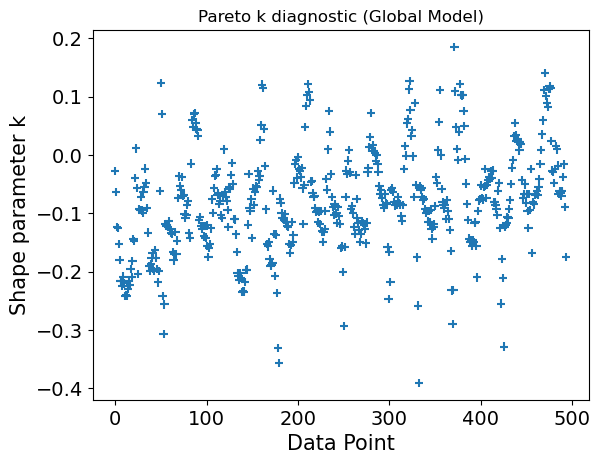

In [8]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + np.log(C_KOH_in)
    log_rate = observables(log_rate_model) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.124  0.002  -0.128   -0.120        0.0      0.0    1161.0    1717.0    1.0
deltaG4_0  0.001  0.013  -0.020    0.028        0.0      0.0    1036.0    1127.0    1.0
Gact2_0    0.748  0.001   0.747    0.749        0.0      0.0    1177.0    1857.0    1.0
beta_2     0.272  0.006   0.260    0.284        0.0      0.0     958.0    1314.0    1.0


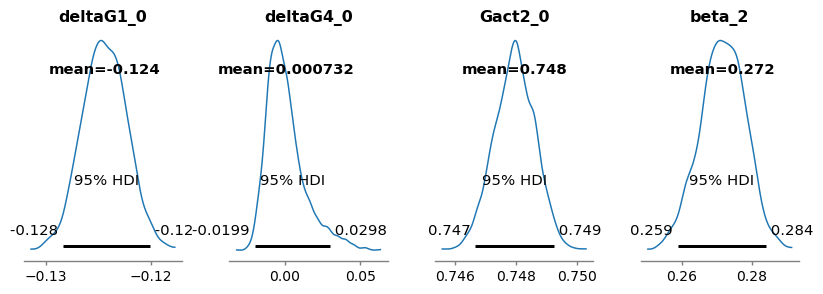

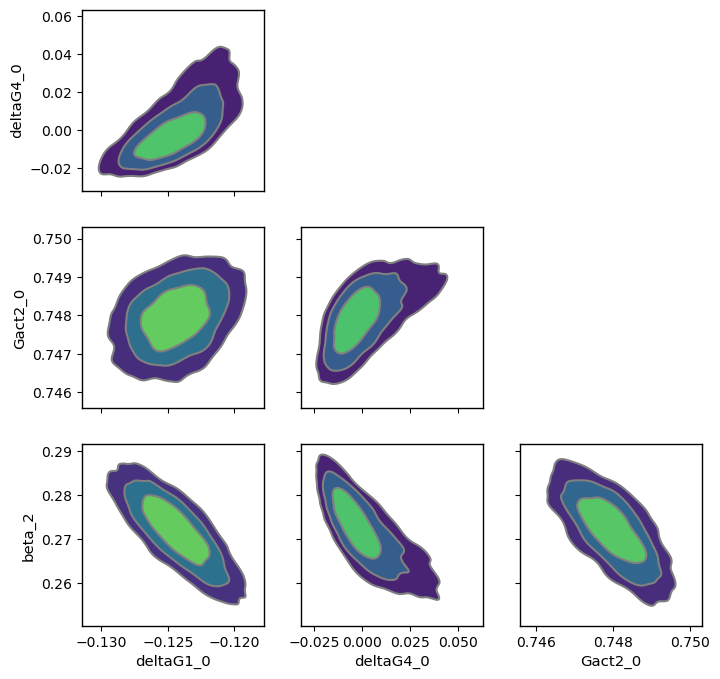

Sampling: [rate]


rate: 0.810


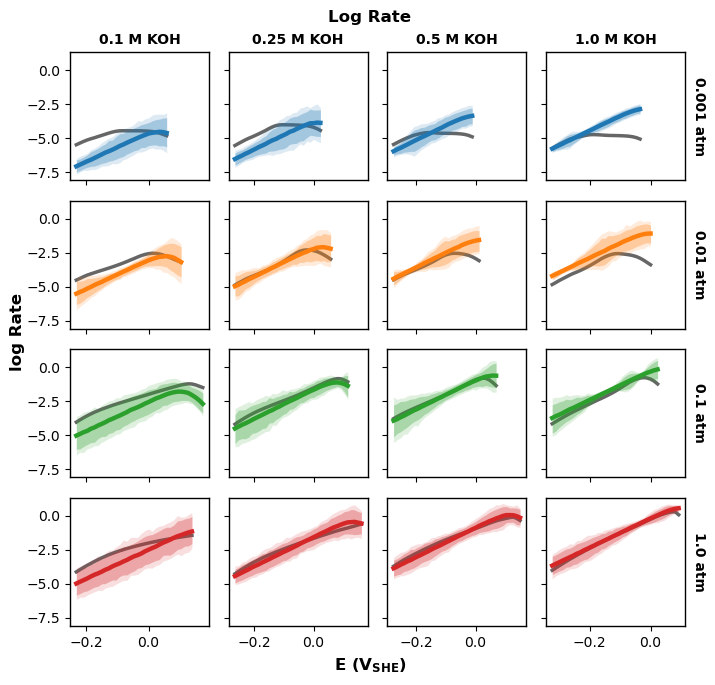

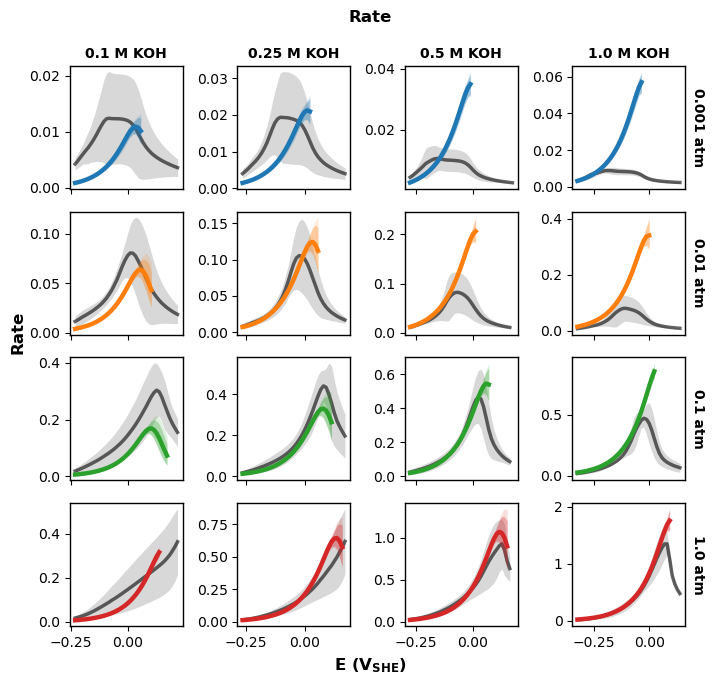

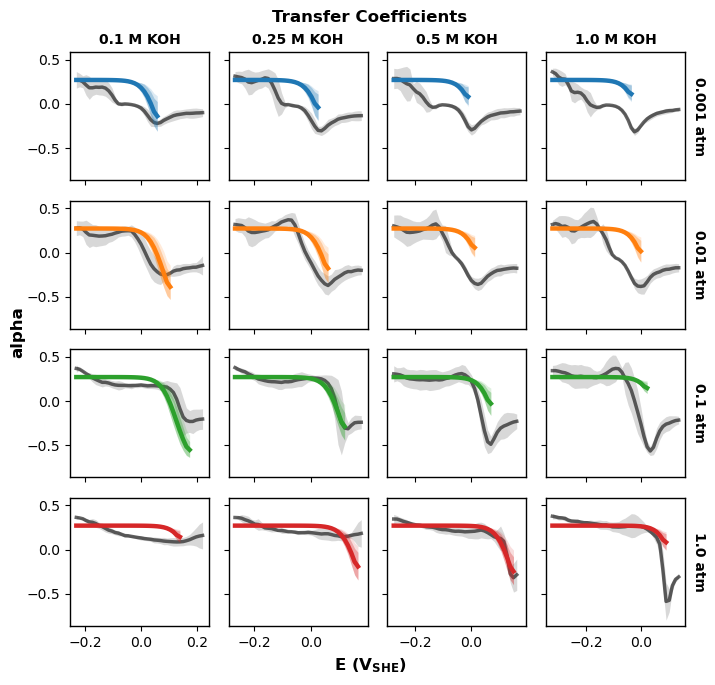

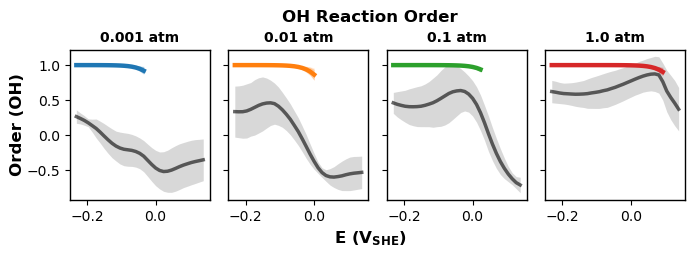

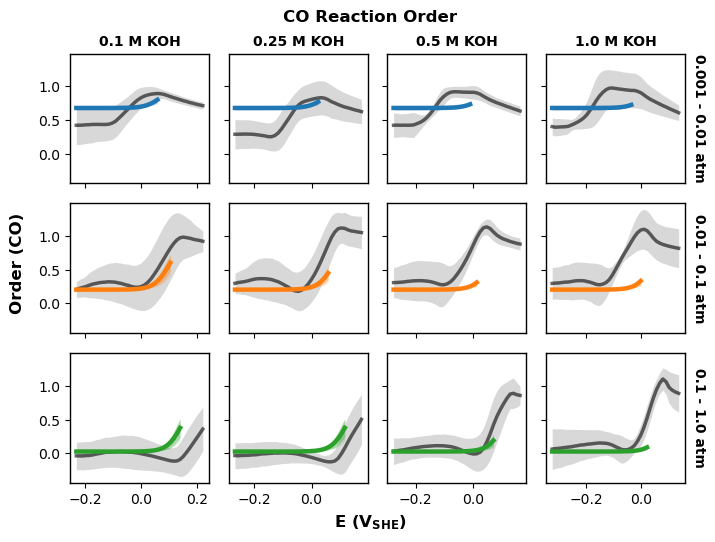

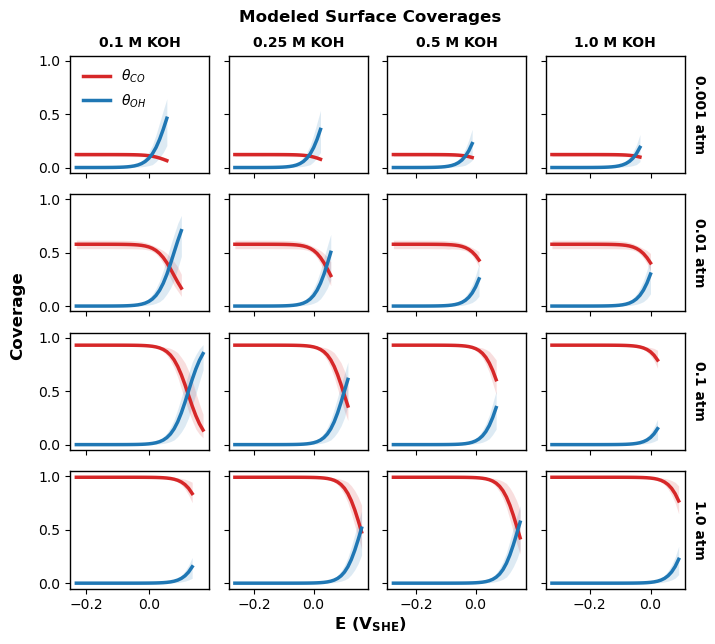

In [9]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, plot_target)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.46,7
,3000,0,0.46,7
,3000,0,0.40,15
,3000,0,0.42,15


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -559.67    39.39
p_loo       26.44        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



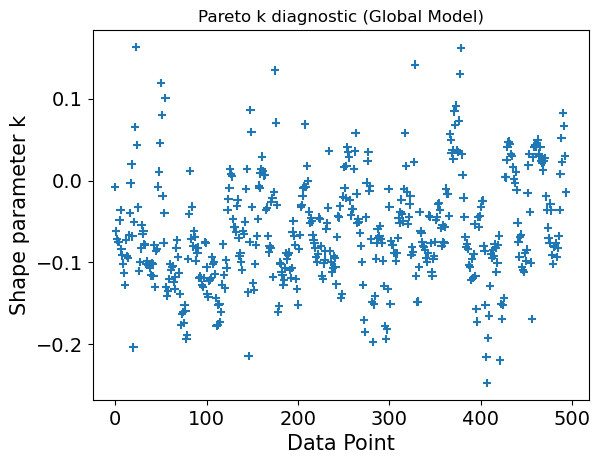

In [11]:
with pm.Model() as ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.3, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=2, beta=2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1) 

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  -0.025  0.009  -0.041   -0.008        0.0      0.0    1352.0    2034.0   1.00
Gact2_ER_0  0.748  0.001   0.747    0.749        0.0      0.0    1377.0    1869.0   1.00
Gact2_LH_0  0.769  0.006   0.758    0.781        0.0      0.0    1417.0    1506.0   1.00
deltaG1_0  -0.122  0.002  -0.126   -0.118        0.0      0.0    1213.0    1644.0   1.01
beta_2      0.268  0.007   0.255    0.281        0.0      0.0    1041.0    1445.0   1.00


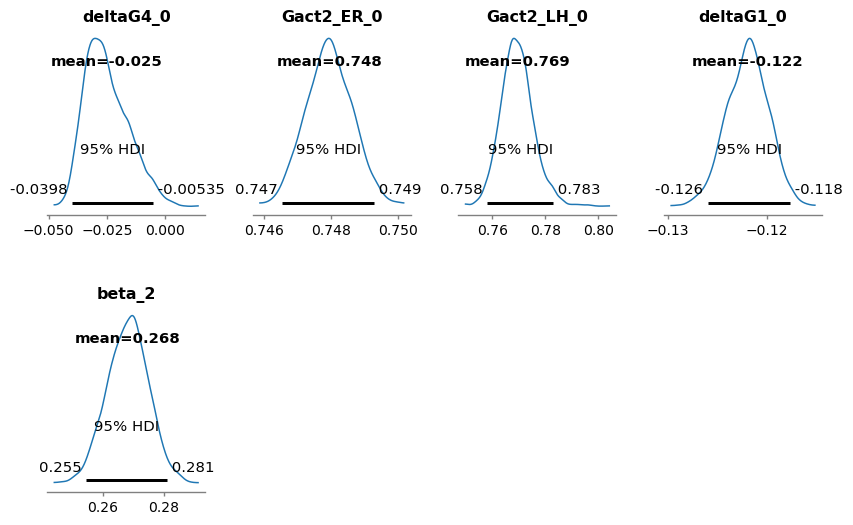

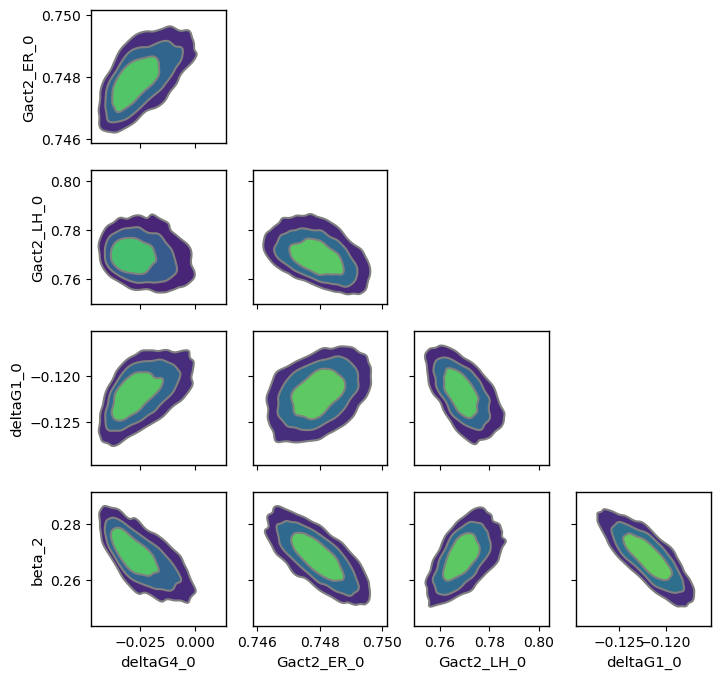

Sampling: [rate]


rate: 0.808


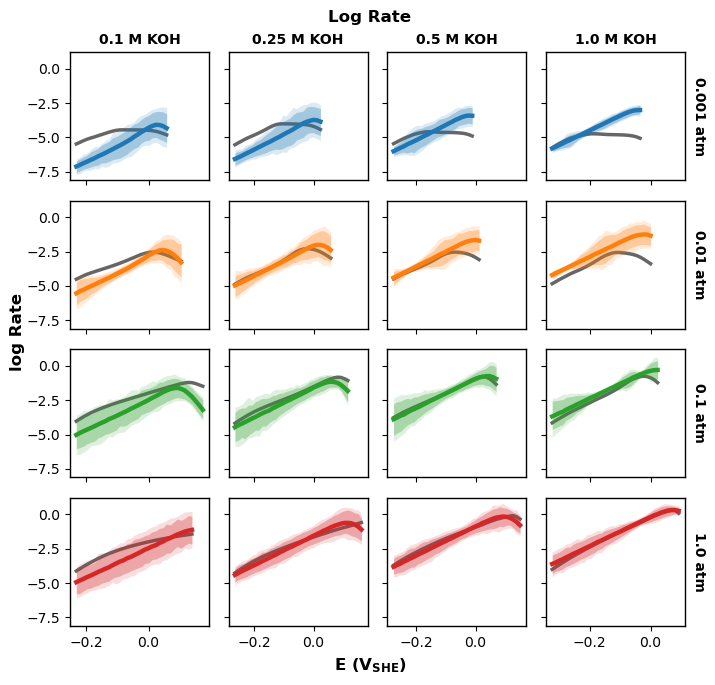

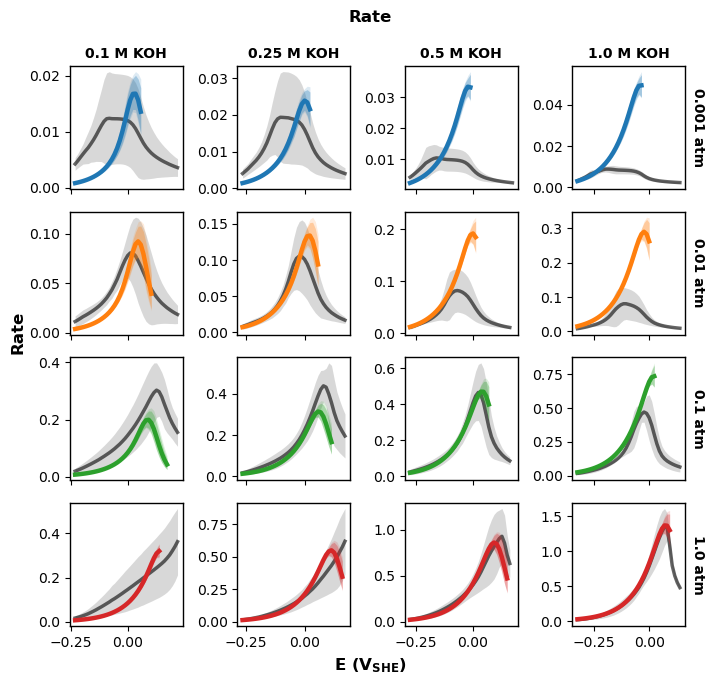

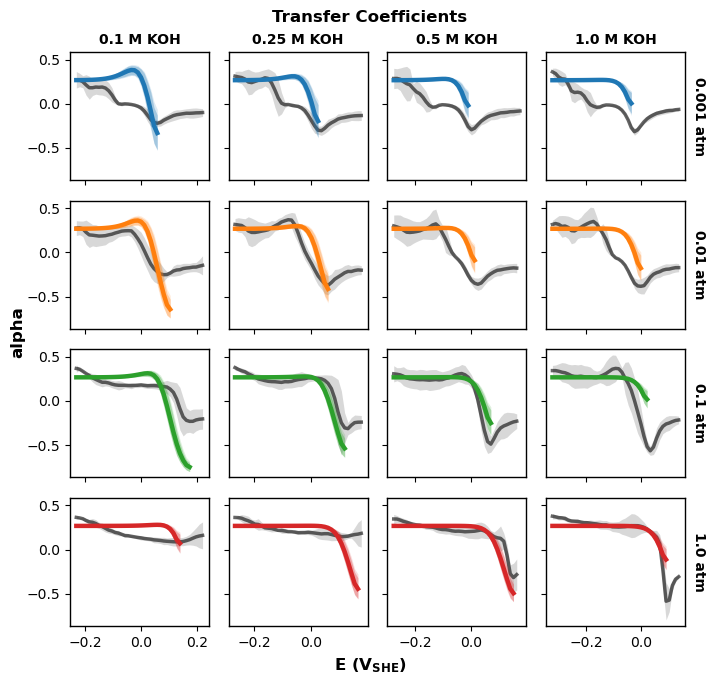

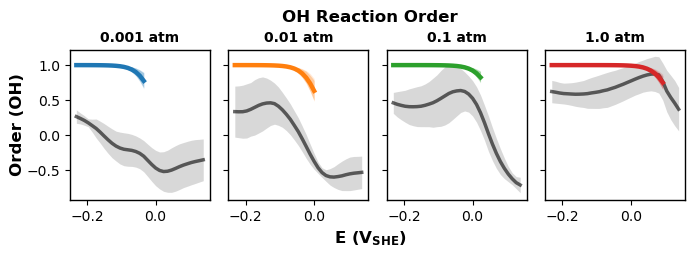

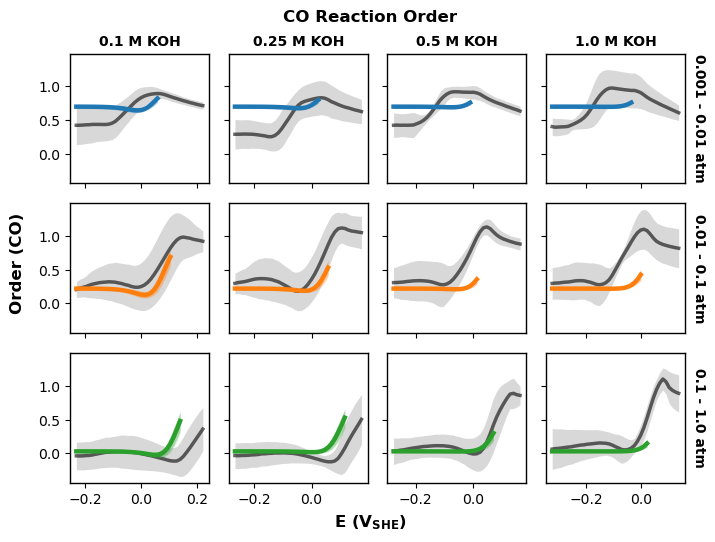

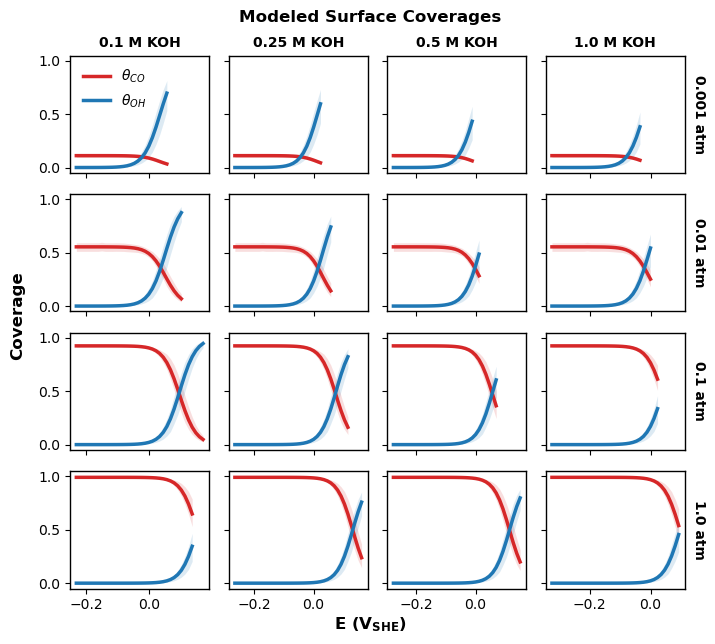

In [12]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2, plot_target)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)

# ER LH 2 Lateral

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.26,15
,3000,0,0.26,15
,3000,0,0.31,31
,3000,0,0.27,15


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -148.18    24.43
p_loo       11.07        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



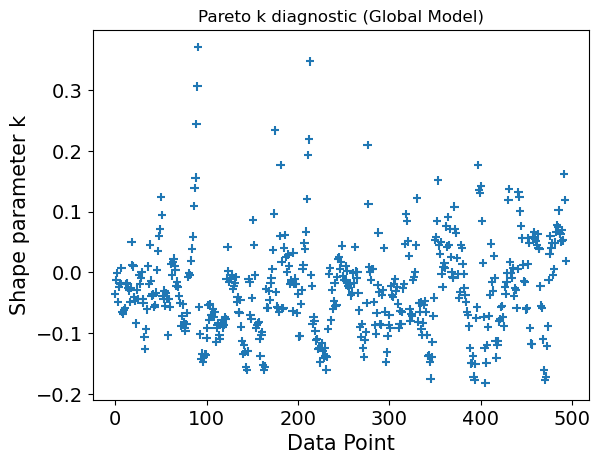

In [15]:
with pm.Model() as ER_LH_2_lateral:
    '''
    1. CO + * <-> CO* (QEA Frumkin)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.3, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=2.0, beta=2.0)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 =  pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1) 
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.3)
    z_OH = pm.Normal('z_OH', mu=0.4, sigma=0.2)

    # Thermodynamics
    deltaG1_base = deltaG1_0
    deltaG4_base = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1_base = -deltaG1_base/(kb_eV*T)
    log_K4_base = -deltaG4_base/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    # Initial guess: No interactions
    term_CO_base = log_K1_base + np.log(P_CO_in)
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)
    
    # Iterative solver setup
    n_iter_steps = 15
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, term_CO_base, term_OH_base, z_CO, z_OH, kb_T, zeros):
        penalty_CO = z_CO * theta_CO_prev / kb_T
        penalty_OH = z_OH * theta_OH_prev / kb_T
        term_CO_iter = term_CO_base - penalty_CO
        term_OH_iter = term_OH_base - penalty_OH
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new

    theta_CO_seq, theta_OH_seq = pytensor.scan(fn=frumkin_step, sequences=[damp_array], outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[term_CO_base, term_OH_base, z_CO, z_OH, kb_eV * T, zeros], n_steps=n_iter_steps, return_updates=False)

    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]
    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)

    term_CO_final = term_CO_base - (z_CO * theta_CO_final) / (kb_eV * T)
    term_OH_final = term_OH_base - (z_OH * theta_OH_final) / (kb_eV * T)
    log_theta_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_final]), axis=0)
    log_theta_CO = term_CO_final + log_theta_final
    log_theta_OH = term_OH_final + log_theta_final

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(log_rate_ER, log_rate_LH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2_lateral, loo_ER_LH_2_lateral = fit_and_evaluate(ER_LH_2_lateral, target_accept=0.92)

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0         -0.283  0.005  -0.293   -0.273        0.0      0.0    1906.0    2206.0    1.0
Gact2_ER_0         0.727  0.002   0.723    0.732        0.0      0.0    1297.0    1342.0    1.0
Gact2_LH_0         0.775  0.002   0.771    0.779        0.0      0.0    1577.0    1648.0    1.0
z_OH               0.284  0.014   0.258    0.313        0.0      0.0    1552.0    1965.0    1.0
deltaG1_0         -0.124  0.002  -0.128   -0.120        0.0      0.0    1885.0    2290.0    1.0
beta_2             0.418  0.012   0.393    0.440        0.0      0.0    1561.0    1769.0    1.0
z_CO               0.108  0.011   0.088    0.130        0.0      0.0    2407.0    2482.0    1.0
CO_converge_error  0.000  0.000   0.000    0.000        0.0      0.0    1831.0    1956.0    1.0
OH_converge_error  0.000  0.000   0.000    0.000        0.0      0.0    2362.0    2546.0    1.0


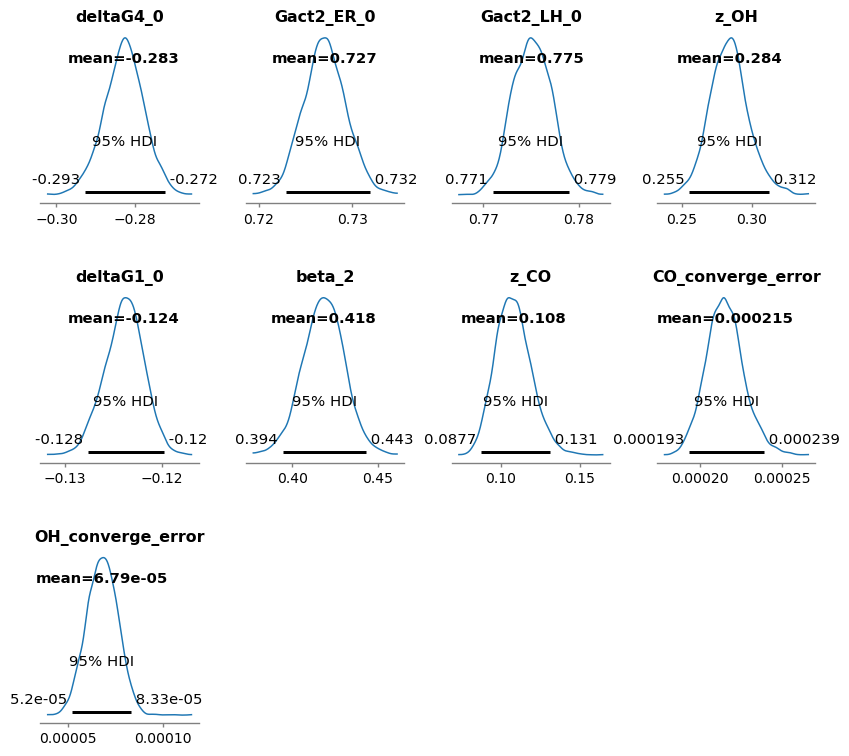

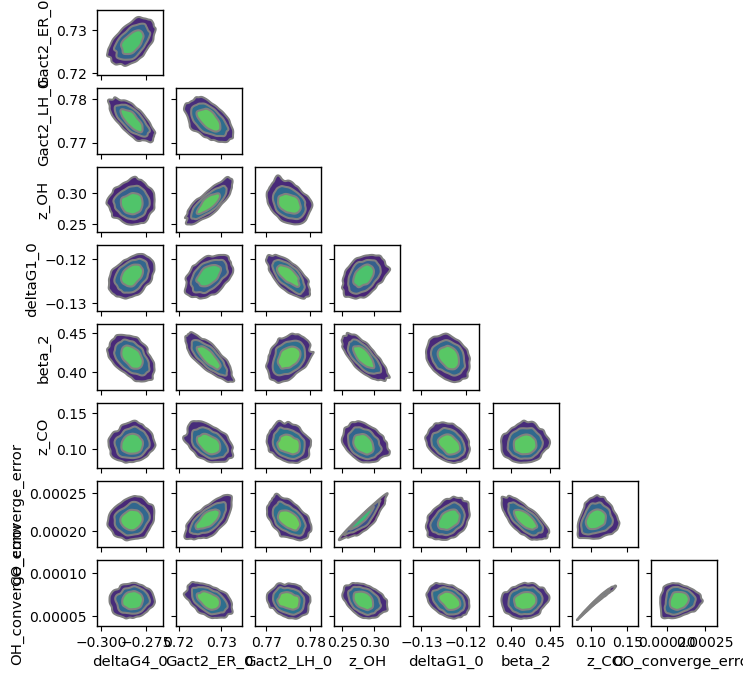

Sampling: [rate]


rate: 0.861


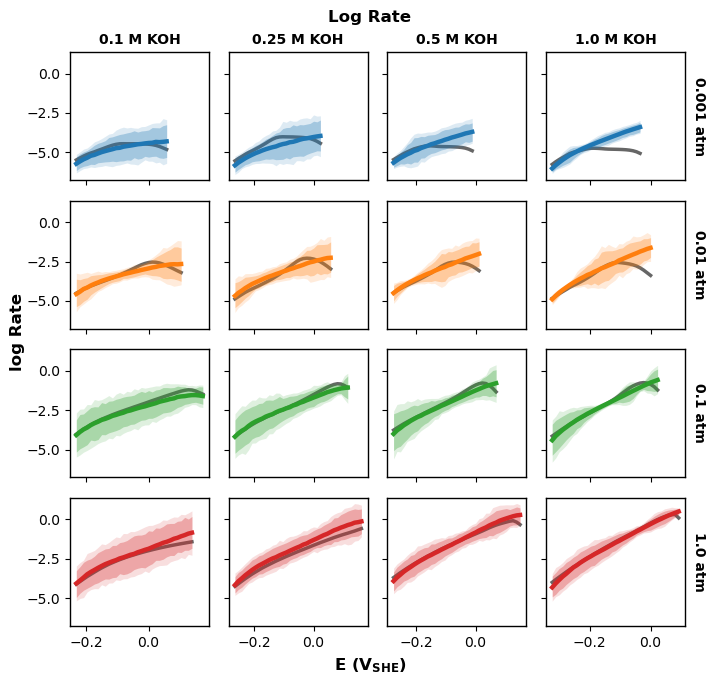

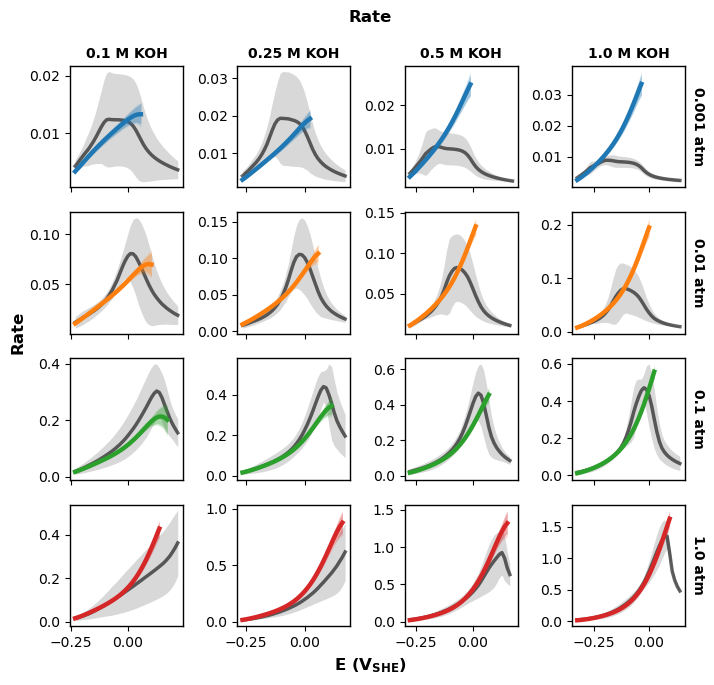

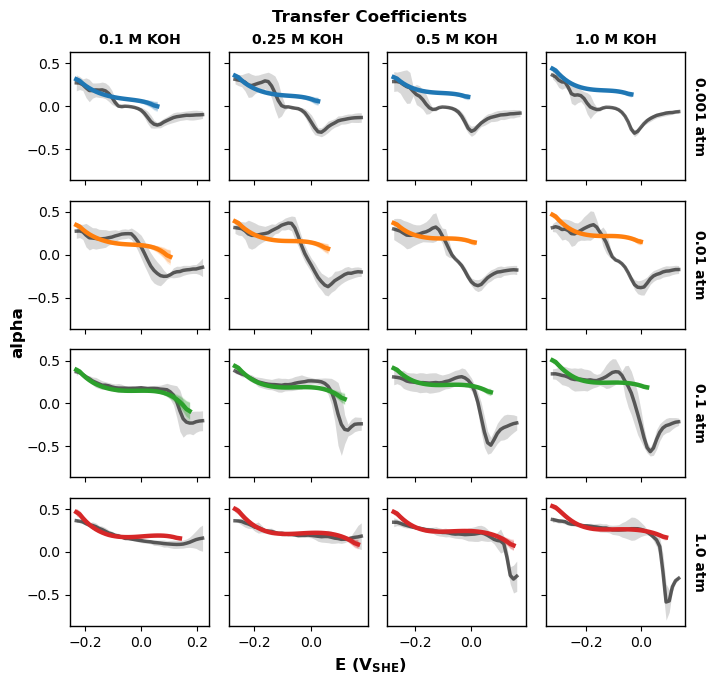

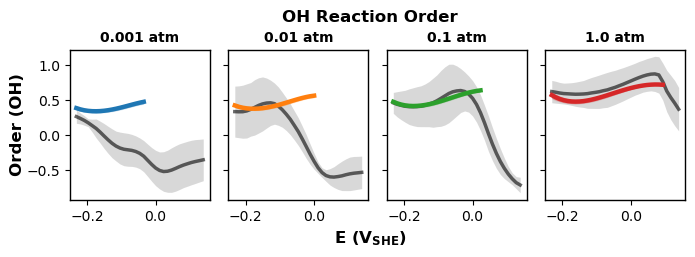

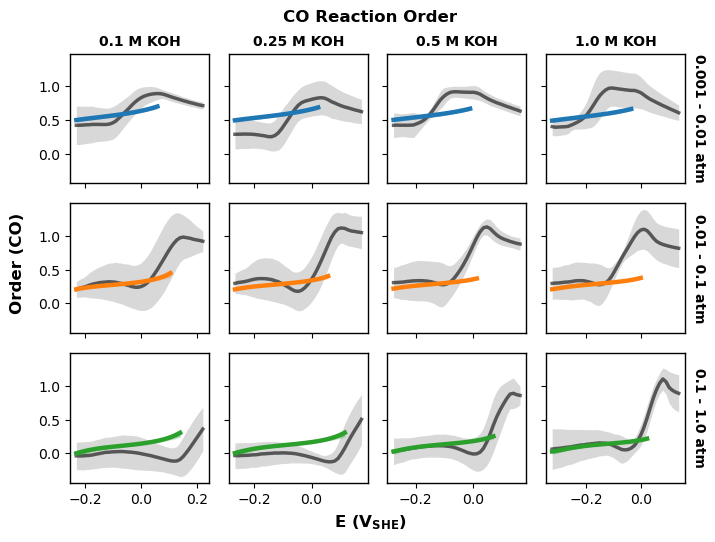

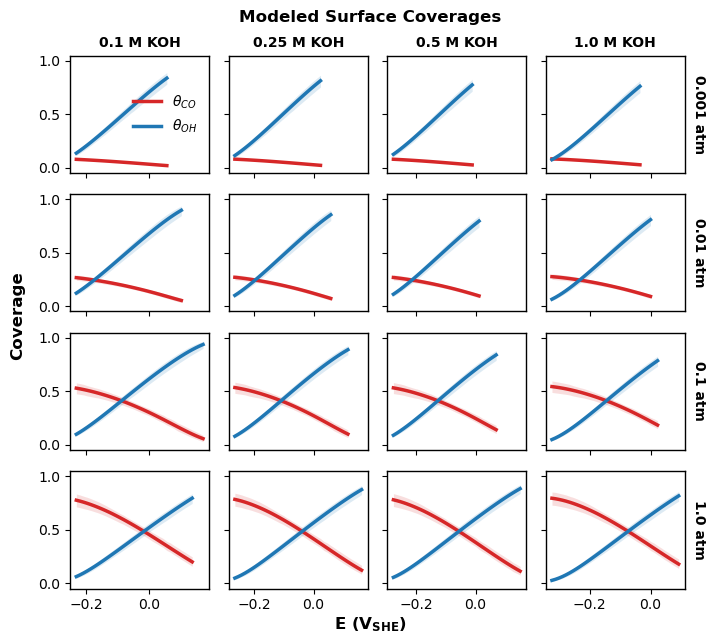

In [16]:
ppc_ER_LH_2_lateral = plot_posteriors(trace_ER_LH_2_lateral, ER_LH_2_lateral, plot_target)
plot_model_fits(trace_ER_LH_2_lateral, ppc_ER_LH_2_lateral); plot_coverages(trace_ER_LH_2_lateral)

# ER LH 2 3 Lateral 

In [ ]:
with pm.Model() as ER_LH_2_3_lateral:
    '''
    1. CO + * <-> CO* (QEA Frumkin)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors 
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.3, sigma=0.15, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0, sigma=0.2) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.4, sigma=0.1)
    beta_2 = pm.Beta('beta_2', alpha=2.0, beta=2.0)
    beta_3 = pm.Beta('beta_3', alpha=2.0, beta=2.0)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 =  pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1) 
    Gact3_0 = pm.Normal('Gact3_0', mu=0.6, sigma=0.1)
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.3)
    z_OH = pm.Normal('z_OH', mu=0.4, sigma=0.2)
    z_cross = 0.0
    
    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0 
    Gact3 = Gact3_0 - beta_3*E_in
    
    log_K1_base = -deltaG1/(kb_eV*T) 
    log_K4_base = -deltaG4/(kb_eV*T) 
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_prefactor = np.log(kb_J*T/h)
    log_k2_ER = log_prefactor - Gact2_ER/(kb_eV*T)
    log_k2_LH = log_prefactor - Gact2_LH/(kb_eV*T)
    log_k3 = log_prefactor - Gact3/(kb_eV*T)

    log_k2_ER_f = log_k2_ER + np.log(C_KOH_in)
    log_k2_ER_b = log_k2_ER - log_K2_ER
    log_k2_LH_f = log_k2_LH
    log_k2_LH_b = log_k2_LH - log_K2_LH
    log_k3 = log_k3 + np.log(C_KOH_in)

    # Initial guess
    term_CO_base = log_K1_base + np.log(P_CO_in)
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    shift_COOH_init = log_k2_ER_f - pt.logaddexp(log_k2_ER_b, log_k3)
    term_COOH_base = term_CO_base + shift_COOH_init
    zeros = pt.zeros_like(term_CO_base)
    log_theta_init = - pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base, term_COOH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)
    theta_COOH_guess = pt.exp(term_COOH_base + log_theta_init)
    
    # Iterative solver setup
    n_iter_steps = 24
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))
    
    def frumkin_root_step(damp, theta_CO_prev, theta_OH_prev, theta_COOH_prev, 
                          term_CO_base, term_OH_base, 
                          log_k2_ER_f, log_k2_ER_b, log_k2_LH_f, log_k2_LH_b, log_k3, 
                          z_CO, z_OH, z_cross, kb_eV_T, zeros):
        
        theta_prev = pt.maximum(1.0 - theta_CO_prev - theta_OH_prev - theta_COOH_prev, 1e-12)
        penalty_CO = (z_CO * theta_CO_prev + z_cross * theta_OH_prev) / kb_eV_T
        penalty_OH = (z_OH * theta_OH_prev + z_cross * theta_CO_prev) / kb_eV_T
        term_CO_iter = term_CO_base - penalty_CO
        term_OH_iter = term_OH_base - penalty_OH
        
        num_COOH = pt.exp(log_k2_ER_f) + pt.exp(log_k2_LH_f) * theta_OH_prev
        den_COOH = pt.exp(log_k2_ER_b) + pt.exp(log_k2_LH_b) * theta_prev + pt.exp(log_k3)
        shift_COOH_iter = pt.log(num_COOH) - pt.log(den_COOH)
        term_COOH_iter = term_CO_iter + shift_COOH_iter 
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter, term_COOH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        theta_COOH_calc = pt.exp(term_COOH_iter + log_theta_iter)
        
        # Dampened update
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        theta_COOH_new = damp * theta_COOH_calc + (1.0 - damp) * theta_COOH_prev
        
        return theta_CO_new, theta_OH_new, theta_COOH_new

    theta_CO_seq, theta_OH_seq, theta_COOH_seq = pytensor.scan(
        fn=frumkin_root_step, sequences=[damp_array], outputs_info=[theta_CO_guess, theta_OH_guess, theta_COOH_guess],
        non_sequences=[term_CO_base, term_OH_base, log_k2_ER_f, log_k2_ER_b, log_k2_LH_f, log_k2_LH_b, log_k3, 
                       z_CO, z_OH, z_cross, kb_eV * T, zeros], n_steps=n_iter_steps, return_updates=False)
    theta_CO_final = theta_CO_seq[-1]; theta_OH_final = theta_OH_seq[-1]; theta_COOH_final = theta_COOH_seq[-1]
    theta_final = pt.maximum(1.0 - theta_CO_final - theta_OH_final - theta_COOH_final, 1e-12)
    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)
    
    term_CO_final = term_CO_base - (z_CO * theta_CO_final + z_cross * theta_OH_final) / (kb_eV * T)
    term_OH_final = term_OH_base - (z_OH * theta_OH_final + z_cross * theta_CO_final) / (kb_eV * T)
    num_COOH_final = pt.exp(log_k2_ER_f) + pt.exp(log_k2_LH_f) * theta_OH_final
    den_COOH_final = pt.exp(log_k2_ER_b) + pt.exp(log_k2_LH_b) * theta_final + pt.exp(log_k3)
    shift_COOH_final = pt.log(num_COOH_final) - pt.log(den_COOH_final)
    term_COOH_final = term_CO_final + shift_COOH_final 
    
    log_theta_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_final, term_COOH_final]), axis=0) 
    log_theta_CO = term_CO_final + log_theta_final
    log_theta_OH = term_OH_final + log_theta_final
    log_theta_COOH = term_COOH_final + log_theta_final

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH
    log_rate = observables(log_rate_model)

trace_ER_LH_2_3_lateral, loo_ER_LH_2_3_lateral = fit_and_evaluate(ER_LH_2_3_lateral, target_accept=0.95)

Output()

deltaG4_0: -0.3095550115316964
deltaG2_ER_0: -0.520754572126881
Gact2_ER_0: 0.7213460191023974
Gact2_LH_0: 0.7423934717927495
Gact3_0: 0.6842184939648588
z_OH: 0.3402181562804572
deltaG1_0: -0.09353224979156224
beta_2: 0.42646217526455793
beta_3: 0.47323801730167137
z_CO: 0.2051595985856644
CO_converge_error: 0.001295139877205198
OH_converge_error: 0.00018832209247768295
theta_CO: [0.02003714 0.01991323 0.01979035 0.0196539  0.01949171 0.01929407
 0.01905376 0.01876607 0.0184285  0.01804037 0.01760232 0.01711594
 0.01658379 0.01600923 0.0153961  0.01474837 0.01406999 0.01336476
 0.01263639 0.01188846 0.01112455 0.01034828 0.00956333 0.00877353
 0.00798291 0.00719581 0.06208294 0.06230021 0.06281426 0.06355656
 0.06445782 0.06544801 0.06645527 0.06740678 0.06823563 0.06888789
 0.06932394 0.06951351 0.06942604 0.0690346  0.06832888 0.06731279
 0.0659973  0.06439546 0.06251998 0.06038284 0.05799661 0.05537637
 0.05254032 0.04950812 0.04629942 0.04293404 0.03943312 0.03582045
 0.03212457 0

In [ ]:
ppc_ER_LH_2_3_lateral = plot_posteriors(trace_ER_LH_2_3_lateral, ER_LH_2_3_lateral, plot_target)
plot_model_fits(trace_ER_LH_2_3_lateral, ppc_ER_LH_2_3_lateral); plot_coverages(trace_ER_LH_2_3_lateral)

# Comparison

                 rank    elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
ER_LH_2_lateral     0 -148.176652  11.071092    0.000000  1.000000e+00  24.429335   0.000000    False   log
ER_LH_2             1 -559.674203  26.438284  411.497551  0.000000e+00  39.394696  33.227893    False   log
ER_2                2 -568.012289  20.693297  419.835638  1.942890e-14  39.051800  32.162272    False   log


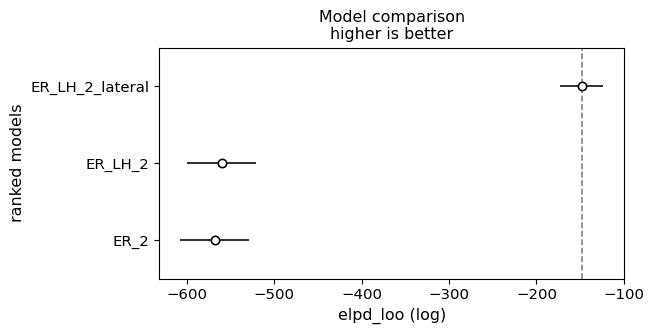

In [ ]:
comparison_dict = {
    'ER_2': loo_ER_2,
    "ER_LH_2": loo_ER_LH_2,
    "ER_LH_2_lateral": loo_ER_LH_2_lateral,
    "ER_LH_2_3_lateral": loo_ER_LH_2_3_lateral, 
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()